# BSL Gesture Recognition - Latency Benchmark (CPU Arduino-aligned)

This notebook measures inference-only latency on CPU to match Arduino on-device protocol.

- Protocol: inference-only (preprocessing done once), µs resolution
- Models: 1D_CNN (TFLite), LightGBM/XGBoost (20-dim features), ADANN, ADANN_LightGBM
- Training modes: standard / loso
- Batch: fixed to 1



In [ ]:
# Section 1: Environment setup & libraries
%pip install tensorflow lightgbm xgboost pandas numpy matplotlib seaborn psutil optuna --quiet

import time
import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import lightgbm as lgb
import xgboost as xgb
import torch

warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()} (will force CPU)")


TensorFlow version: 2.19.0
PyTorch CUDA available: False (will force CPU)


In [ ]:
# Section 2: Mount drive & set working directory (Colab-friendly)
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    import os
    project_root = "/content/drive/My Drive/Project"
    if not os.path.exists(project_root):
        project_root = "/content/drive/MyDrive/Project"
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")
except Exception:
    import os
    print("Colab drive not mounted, using current working directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/My Drive/Project


In [ ]:
# Section 2: CPU Arduino-aligned benchmark class
class CpuArduinoLatencyBenchmark:
    def __init__(self, arduino_only: bool = True):
        # arduino_only=True enforces using only models under .../arduino; no fallback to full
        self.arduino_only = arduino_only
        self.results = []
        self.device = torch.device('cpu')
        self.num_warmup = 50
        self.num_runs = 1000
        self.batch_sizes = [1]
        self.sample_data_dl = np.random.randn(1, 100, 5).astype(np.float32)
        self.sample_data_ml_flat = self.sample_data_dl.reshape(1, -1)
        self._now = time.perf_counter_ns
        self._overhead_ns = self._estimate_timer_overhead_ns()
        # Pin threads to 1 for fair MCU-like comparison
        try:
            import os
            os.environ.setdefault('OMP_NUM_THREADS', '1')
            os.environ.setdefault('MKL_NUM_THREADS', '1')
            torch.set_num_threads(1)
            torch.set_num_interop_threads(1)
        except Exception:
            pass
        print(f"Device: {self.device} | Runs: {self.num_runs}, Warmup: {self.num_warmup} | Arduino-only: {self.arduino_only}")

    @staticmethod
    def _first_existing_dir(candidates):
        for d in candidates:
            if os.path.exists(d):
                return d
        return candidates[0]

    def _estimate_timer_overhead_ns(self, iters: int = 10000) -> int:
        best = 1 << 60
        for _ in range(iters):
            t0 = self._now(); t1 = self._now(); dt = t1 - t0
            if dt < best: best = dt
        return best

    @staticmethod
    def _ema_filter(window_100x5: np.ndarray, alpha: float = 0.1) -> np.ndarray:
        out = np.empty_like(window_100x5, dtype=np.float32)
        out[0, :] = window_100x5[0, :]
        for ch in range(window_100x5.shape[1]):
            ema = float(window_100x5[0, ch]); out[0, ch] = ema
            for t in range(1, window_100x5.shape[0]):
                ema = alpha * float(window_100x5[t, ch]) + (1.0 - alpha) * ema
                out[t, ch] = ema
        return out

    @staticmethod
    def _features_20_from_window(window_100x5: np.ndarray) -> np.ndarray:
        feats = []
        for ch in range(window_100x5.shape[1]):
            x = window_100x5[:, ch].astype(np.float32)
            mean = float(np.mean(x))
            std = float(np.sqrt(max(0.0, float(np.mean(x * x) - mean * mean))))
            mn = float(np.min(x)); mx = float(np.max(x))
            feats.extend([mean, std, mn, mx])
        return np.array(feats, dtype=np.float32).reshape(1, -1)

    def _load_tflite_model(self, model_path: str):
        try:
            # Try to emulate MCU-like runtime a bit: single thread and disable XNNPACK
            try:
                interpreter = tf.lite.Interpreter(model_path=model_path, num_threads=1, experimental_options={'use_xnnpack': False})
            except TypeError:
                interpreter = tf.lite.Interpreter(model_path=model_path)
                try:
                    interpreter.set_num_threads(1)
                except Exception:
                    pass
            interpreter.allocate_tensors()
            return interpreter, 'tflite'
        except Exception as e:
            print(f"load TFLite fail: {e}"); return None, None

    def _load_ml_model(self, model_path: str, model_type: str):
        try:
            import pickle, sys
            if '.' not in sys.path: sys.path.insert(0, '.')
            with open(model_path, 'rb') as f:
                if model_type == 'LightGBM':
                    from src.training.train_lightgbm import LightgbmModelCreator
                data = pickle.load(f)
            model = data.get('lgb_model') or data.get('model', data) if isinstance(data, dict) else data
            return model, model_type.lower()
        except Exception as e:
            print(f"load {model_type} file: {e}"); return None, None

    def _load_pytorch_or_keras_package(self, model_path: str, model_type: str):
        try:
            pkg = torch.load(model_path, map_location='cpu', weights_only=False)
            if isinstance(pkg, dict):
                for v in pkg.values():
                    if hasattr(v, 'eval'): v.eval()
            elif hasattr(pkg, 'eval'):
                pkg.eval()
            return pkg, 'torch'
        except Exception:
            pass
        try:
            if model_path.endswith('.keras'):
                model = tf.keras.models.load_model(model_path)
                return model, 'keras'
        except Exception as e:
            print(f"load {model_type} as Keras fail: {e}")
        return None, None

    def _inference_once(self, model, framework: str, model_type: str, payload):
        if framework == 'tflite':
            model.invoke(); return
        if framework in ['lightgbm', 'xgboost']:
            x = payload
            try: _ = model.predict_proba(x)
            except Exception: _ = model.predict(x)
            return
        if framework == 'torch':
            with torch.no_grad():
                if isinstance(payload, dict) and 'adann' in payload:
                    # ADANN branch
                    if 'x' in payload:
                        _ = payload['adann'](payload['x'])
                    else:
                        _ = payload['adann'](payload['x_adann'])
                    # Optional LightGBM branch for Hybrid
                    if 'lgbm' in payload and 'x_lgb' in payload:
                        try:
                            _ = payload['lgbm'].predict_proba(payload['x_lgb'])
                        except Exception:
                            _ = payload['lgbm'].predict(payload['x_lgb'])
                else:
                    _ = model(payload)
            return
        if framework == 'keras':
            _ = model(payload, training=False) if callable(getattr(model, '__call__', None)) else model.predict(payload, verbose=0)
            return
        raise ValueError(f"Unknown framework: {framework}")

    def benchmark_model(self, model_type, model_path, training_mode):
        print(f"\n[Test] {model_type} ({training_mode}), batch_size=1")
        if model_type in ["1D_CNN", "Transformer_Encoder"]:
            # Choose loader by extension: .tflite -> TFLite, .keras -> Keras
            sample_data = self.sample_data_dl
            if model_path.endswith('.tflite'):
                model, framework = self._load_tflite_model(model_path)
            elif model_path.endswith('.keras'):
                try:
                    model = tf.keras.models.load_model(model_path)
                    framework = 'keras'
                except Exception as e:
                    print(f"load Keras fail: {e}"); return None
            else:
                print(f"[Skip] unsupported file extension for {model_type}: {os.path.basename(model_path)}"); return None
        elif model_type in ["LightGBM", "XGBoost"]:
            model, framework = self._load_ml_model(model_path, model_type)
            sample_data = self.sample_data_ml_flat
        else:
            model, framework = self._load_pytorch_or_keras_package(model_path, model_type)
            sample_data = self.sample_data_dl
        if model is None:
            print("[Skip] model load failed"); return None

        # Prepare Arduino-aligned payloads
        if framework == 'tflite':
            input_details = model.get_input_details()[0]
            expected_shape = list(input_details['shape'])
            x = sample_data.copy()
            if x.ndim == 3 and len(expected_shape) == 4 and expected_shape[-1] == 1:
                x = x[..., np.newaxis]
            if input_details['dtype'] in (np.int8, np.uint8):
                scale, zero_point = input_details.get('quantization', (0.0, 0))
                if (isinstance(scale, (list, tuple)) and len(scale) > 0):
                    scale = scale[0]
                if scale == 0.0:
                    qp = input_details.get('quantization_parameters', {})
                    scales = qp.get('scales', [1.0]); zps = qp.get('zero_points', [0])
                    scale = float(scales[0]); zero_point = int(zps[0])
                x_q = np.round(x / scale + zero_point)
                info = np.iinfo(np.int8 if input_details['dtype'] == np.int8 else np.uint8)
                x_q = np.clip(x_q, info.min, info.max).astype(input_details['dtype'])
                x = x_q
            if list(x.shape) != expected_shape:
                model.resize_tensor_input(input_details['index'], list(x.shape), strict=False)
            model.allocate_tensors()
            model.set_tensor(input_details['index'], x)
            payload = None
        elif framework == 'keras':
            # Ensure proper input tensor shape for Keras TFLite-equivalent models
            x = sample_data.copy()
            if x.ndim == 3:
                x = x  # expect (1, 100, 5) for 1D models; user models define their own preprocessing
            payload = x
        elif framework in ['lightgbm', 'xgboost']:
            # Mirror Latency_Test.ipynb: use flattened 100x5=500 and slice to n_features_in_ if present
            x = self.sample_data_ml_flat
            if hasattr(model, 'n_features_in_'):
                n = int(getattr(model, 'n_features_in_'))
                if x.shape[1] != n:
                    x = x[:, :n]
            payload = x
        elif framework == 'torch':
            if model_type == 'ADANN' and isinstance(model, dict):
                adann = model.get('adann_model') or model.get('model_object')
                extractor = model.get('feature_extractor_obj', getattr(adann, 'feature_extractor_obj', None))
                scaler = model.get('scaler', getattr(adann, 'scaler', None))
                if adann is None or extractor is None or scaler is None:
                    print("[Skip] ADANN package missing components"); return None
                window = sample_data.reshape(100, 5)
                feats = extractor.extract_comprehensive_features(window)
                feats = np.asarray(feats, dtype=np.float32).reshape(1, -1)
                feats = scaler.transform(feats).astype(np.float32)
                x = torch.from_numpy(feats)
                if hasattr(adann, 'eval'): adann.eval()
                # Force torch inference on a single thread
                try:
                    torch.set_num_threads(1)
                    torch.set_num_interop_threads(1)
                except Exception:
                    pass
                payload = {'adann': adann, 'x': x}
            elif model_type == 'ADANN_LightGBM' and isinstance(model, dict):
                adann = model.get('adann_model'); lgbm = model.get('lightgbm_model')
                adann_scaler = model.get('adann_scaler'); lgb_scaler = model.get('lgb_scaler')
                extractor = model.get('hybrid_extractor')
                if not all([adann, lgbm, adann_scaler, lgb_scaler, extractor]):
                    print("[Skip] ADANN_LightGBM package missing components"); return None
                window = sample_data.reshape(100, 5)
                x_adann = extractor.enhanced_extractor.extract_comprehensive_features(window)
                x_lgb = extractor.extract_lightgbm_features(window)
                x_adann = adann_scaler.transform(np.asarray(x_adann, dtype=np.float32).reshape(1, -1)).astype(np.float32)
                x_lgb = lgb_scaler.transform(np.asarray(x_lgb, dtype=np.float32).reshape(1, -1)).astype(np.float32)
                x_adann_t = torch.from_numpy(x_adann)
                if hasattr(adann, 'eval'): adann.eval()
                try:
                    torch.set_num_threads(1)
                    torch.set_num_interop_threads(1)
                except Exception:
                    pass
                payload = {'adann': adann, 'x_adann': x_adann_t, 'lgbm': lgbm, 'x_lgb': x_lgb}
            else:
                x = torch.from_numpy(sample_data.astype(np.float32))
                try:
                    torch.set_num_threads(1)
                    torch.set_num_interop_threads(1)
                except Exception:
                    pass
                payload = x
        else:
            payload = sample_data

        # Warmup
        print("Warmup...")
        for _ in range(self.num_warmup):
            try:
                self._inference_once(model, framework, model_type, payload)
            except Exception as e:
                print(f"[Skip] warmup failed: {e}"); return None

        # Measure (report in milliseconds for readability)
        lat_ms = []
        for _ in range(self.num_runs):
            t0 = self._now(); self._inference_once(model, framework, model_type, payload); t1 = self._now()
            dt_ns = max(0, (t1 - t0) - self._overhead_ns)
            lat_ms.append(dt_ns / 1_000_000.0)

        mean_ms = float(np.mean(lat_ms)); std_ms = float(np.std(lat_ms))
        ips = 1000.0 / mean_ms if mean_ms > 0 else 0.0
        print(f"✅ Mean Inference Latency: {mean_ms:.3f}ms | Throughput: {ips:.2f} inf/sec")
        return {
            'model_name': model_type,
            'training_mode': training_mode,
            'batch_size': 1,
            'mean_latency_ms': mean_ms,
            'std_latency_ms': std_ms,
            'throughput_inf_per_sec': ips,
        }

    def find_latest_model(self, model_dir, model_type):
        if not os.path.exists(model_dir): return None, None
        if model_type in ["1D_CNN", "Transformer_Encoder"]: exts = [".tflite", ".keras"]
        elif model_type in ["LightGBM", "XGBoost"]: exts = [".pkl"]
        else: exts = [".pth", ".pt", ".pth.tar", ".keras"]
        files = []
        for f in os.listdir(model_dir):
            if f.startswith('scaler_'): continue
            for ext in exts:
                if f.endswith(ext): files.append(f); break
        files = sorted(files, reverse=True)
        if not files:
            print(f" The dir exists but has not found {model_type} recognizable model file: {model_dir}")
            print(f"   Include files: {sorted(os.listdir(model_dir))[:10]}")
            return None, None
        return os.path.join(model_dir, files[0]), files[0]

    def run_benchmark(self):
        print("Starting Arduino-aligned CPU inference benchmark..."); print("=" * 60)
        # Arduino-only paths; no fallback to full
        models = [
            ("1D_CNN", "models/trained/1D_CNN/standard/arduino", "standard"),
            ("1D_CNN", "models/trained/1D_CNN/loso/arduino", "loso"),
            ("Transformer_Encoder", "models/trained/Transformer_Encoder/standard/arduino", "standard"),
            ("Transformer_Encoder", "models/trained/Transformer_Encoder/loso/arduino", "loso"),
            ("LightGBM", "models/trained/LightGBM/standard/arduino", "standard"),
            ("LightGBM", "models/trained/LightGBM/loso/arduino", "loso"),
            ("XGBoost", "models/trained/XGBoost/standard/arduino", "standard"),
            ("XGBoost", "models/trained/XGBoost/loso/arduino", "loso"),
            ("ADANN", "models/trained/ADANN/standard/arduino", "standard"),
            ("ADANN", "models/trained/ADANN/loso/arduino", "loso"),
            ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/standard/arduino", "standard"),
            ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/loso/arduino", "loso"),
        ]
        res = []
        for model_type, model_dir, training_mode in models:
            model_path, model_name = self.find_latest_model(model_dir, model_type)
            if not model_path:
                print(f"[Skip] {model_type} ({training_mode}) model file not found in {model_dir}"); continue
            # Allow Transformer_Encoder on CPU (TFLite) for testing
            print(f"\n[Model] {model_name} ({training_mode}) @ {model_dir}")
            r = self.benchmark_model(model_type, model_path, training_mode)
            if r is not None: res.append(r)
        if not res:
            print(" There are no test results to save."); return
        df = pd.DataFrame(res); timestamp = time.strftime("%Y%m%d_%H%M%S")
        out_csv = f"latency_benchmark_results_arduino_{timestamp}.csv"
        df.to_csv(out_csv, index=False); print(f"\nSaved results to: {out_csv}")
        self._plots(df, timestamp)

    def _plots(self, df: pd.DataFrame, timestamp: str):
        print("\nGenerating plots..."); plt.style.use('seaborn-v0_8-whitegrid')
        for mode in ['standard', 'loso']:
            mode_df = df[df['training_mode'] == mode].copy()
            if mode_df.empty: continue
            # Clean styling for publication-like plots
            fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=200, gridspec_kw={'width_ratios': [2, 1]})
            fig.suptitle(f'Inference Performance Benchmark ({mode.capitalize()} Training) - Arduino-aligned', fontsize=18, fontweight='bold')

            # Bar: mean latency
            palette = sns.color_palette('deep')
            ax1 = sns.barplot(data=mode_df, x='model_name', y='mean_latency_ms', hue='batch_size', ax=axes[0], palette=palette, edgecolor='black')
            ax1.set_title('Mean Inference Latency (ms)', fontsize=13)
            ax1.set_ylabel('Mean Latency (ms)')
            ax1.set_xlabel('')
            ax1.set_yscale('log')
            ax1.tick_params(axis='x', rotation=15, labelsize=11)
            for p in ax1.patches:
                height = p.get_height()
                if height > 0:
                    ax1.annotate(f"{height:.2f}", (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3), textcoords='offset points')
            ax1.legend(title='Batch Size', loc='upper right', frameon=False)
            ax1.grid(True, which='both', axis='y', ls='--', alpha=0.4)

            # Right panel: horizontal bar chart for throughput (cleaner)
            ax2 = axes[1]
            tb = markers_df = mode_df.sort_values('throughput_inf_per_sec', ascending=True)
            ax2.barh(tb['model_name'], tb['throughput_inf_per_sec'], color=sns.color_palette('deep'))
            for idx, val in enumerate(tb['throughput_inf_per_sec']):
                ax2.annotate(f"{int(val):,}", (val, idx), xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)
            ax2.set_title('Throughput (inf/sec)', fontsize=13)
            ax2.set_xlabel('Throughput (inf/sec)')
            ax2.set_ylabel('')
            ax2.set_xscale('log')
            ax2.grid(True, which='both', axis='x', ls='--', alpha=0.4)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plot_path_png = f"latency_benchmark_plot_arduino_{mode}_{timestamp}.png"; plot_path_pdf = f"latency_benchmark_plot_arduino_{mode}_{timestamp}.pdf"
            plt.savefig(plot_path_png, dpi=300)
            plt.savefig(plot_path_pdf)
            print(f"Saved plots: {plot_path_png}, {plot_path_pdf}")
            plt.show()


Device: cpu | Runs: 1000, Warmup: 50 | Arduino-only: True
Starting Arduino-aligned CPU inference benchmark...

[Model] 1D_CNN_standard_20250812_144758.tflite (standard) @ models/trained/1D_CNN/standard/arduino

[Test] 1D_CNN (standard), batch_size=1
Warmup...
✅ Mean Inference Latency: 0.011ms | Throughput: 92359.01 inf/sec

[Model] 1D_CNN_loso_final_20250812_145620.tflite (loso) @ models/trained/1D_CNN/loso/arduino

[Test] 1D_CNN (loso), batch_size=1
Warmup...
✅ Mean Inference Latency: 0.012ms | Throughput: 85032.89 inf/sec

[Model] Transformer_Encoder_standard_20250812_213038.keras (standard) @ models/trained/Transformer_Encoder/standard/arduino

[Test] Transformer_Encoder (standard), batch_size=1
Warmup...
✅ Mean Inference Latency: 31.182ms | Throughput: 32.07 inf/sec

[Model] Transformer_Encoder_loso_final_20250812_173122.keras (loso) @ models/trained/Transformer_Encoder/loso/arduino

[Test] Transformer_Encoder (loso), batch_size=1
Warmup...
✅ Mean Inference Latency: 32.820ms | Thro

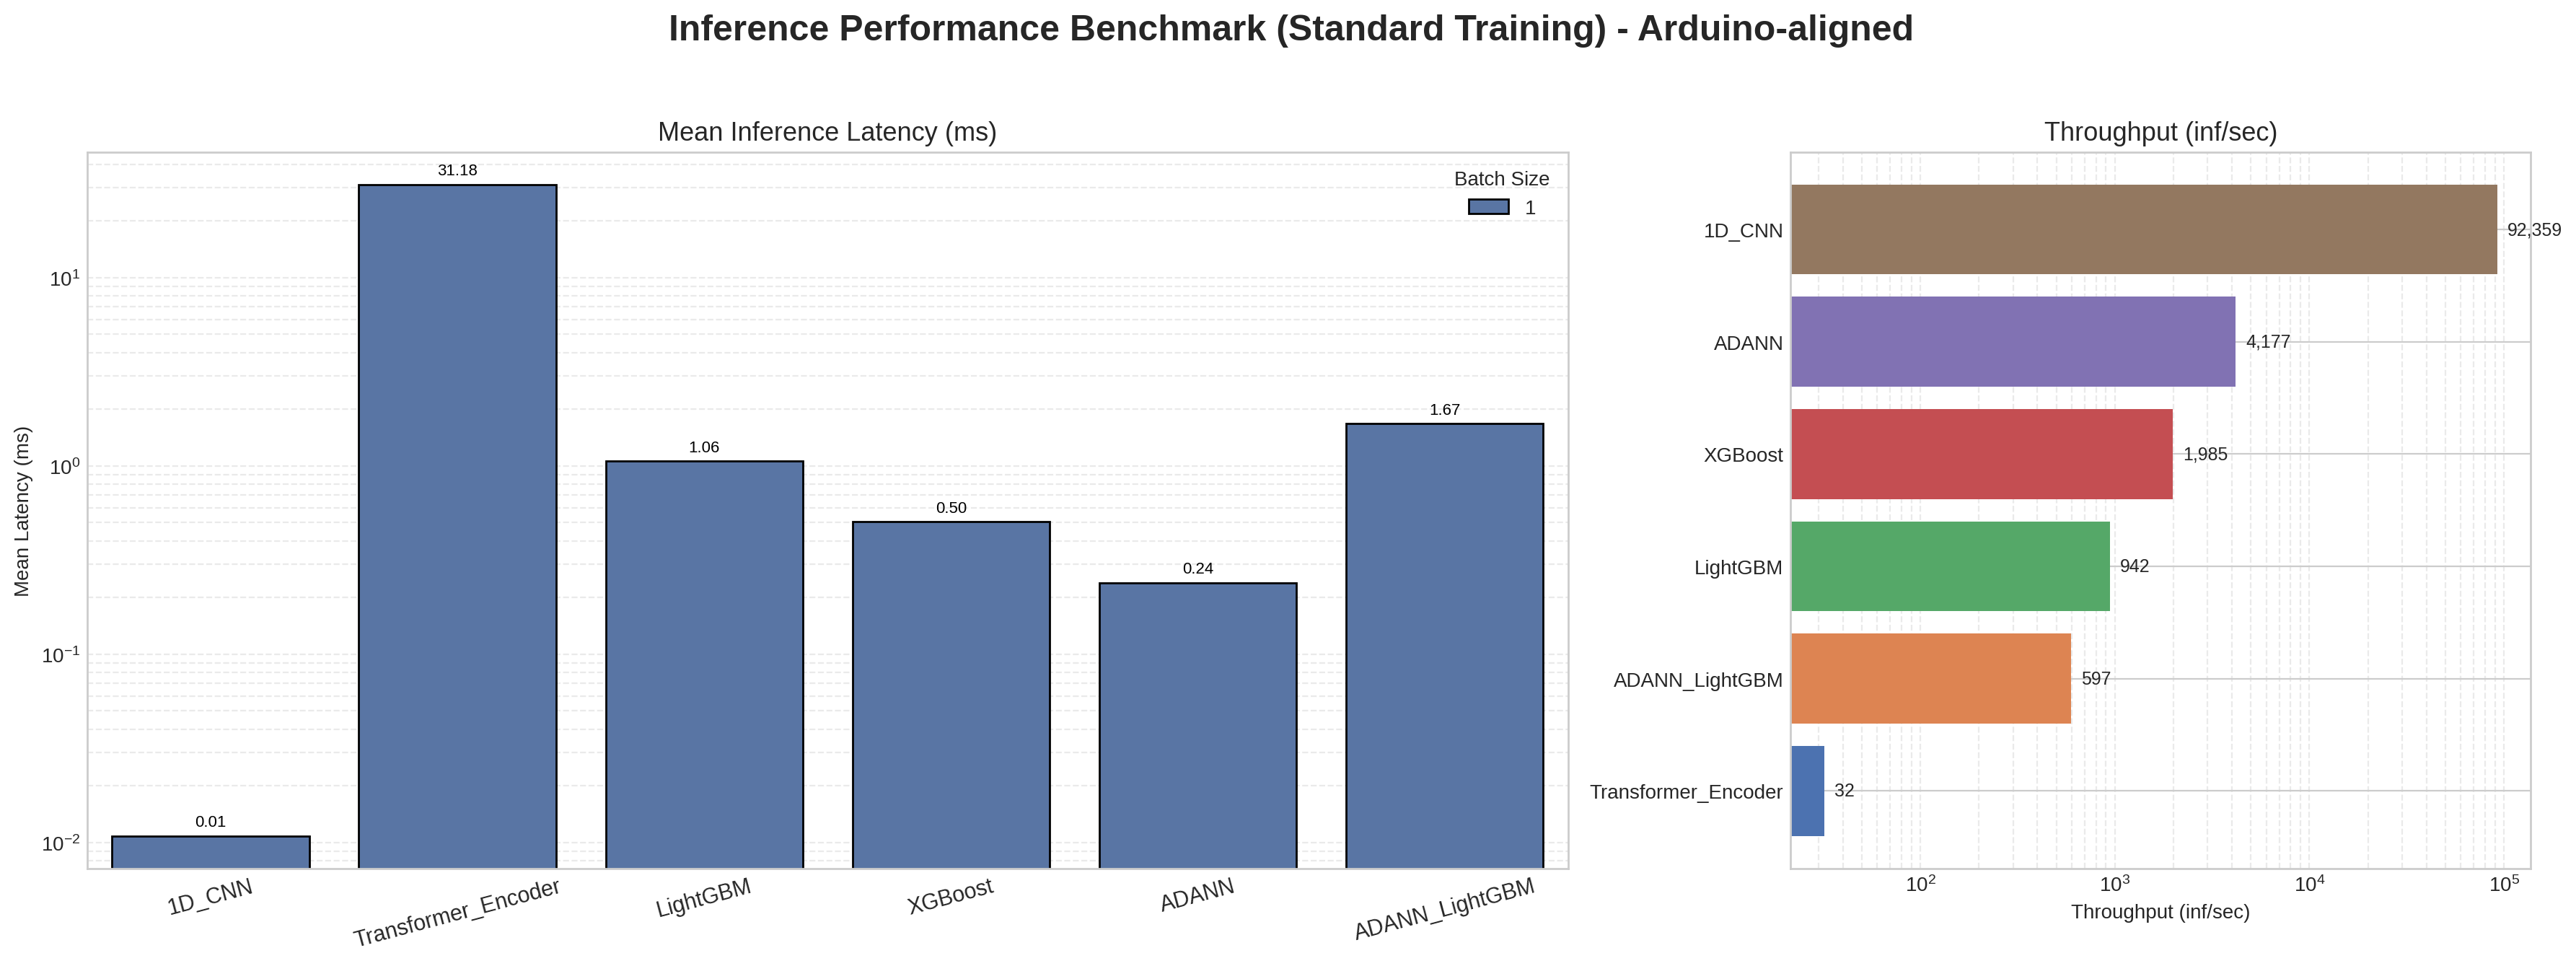

Saved plots: latency_benchmark_plot_arduino_loso_20250812_233442.png, latency_benchmark_plot_arduino_loso_20250812_233442.pdf


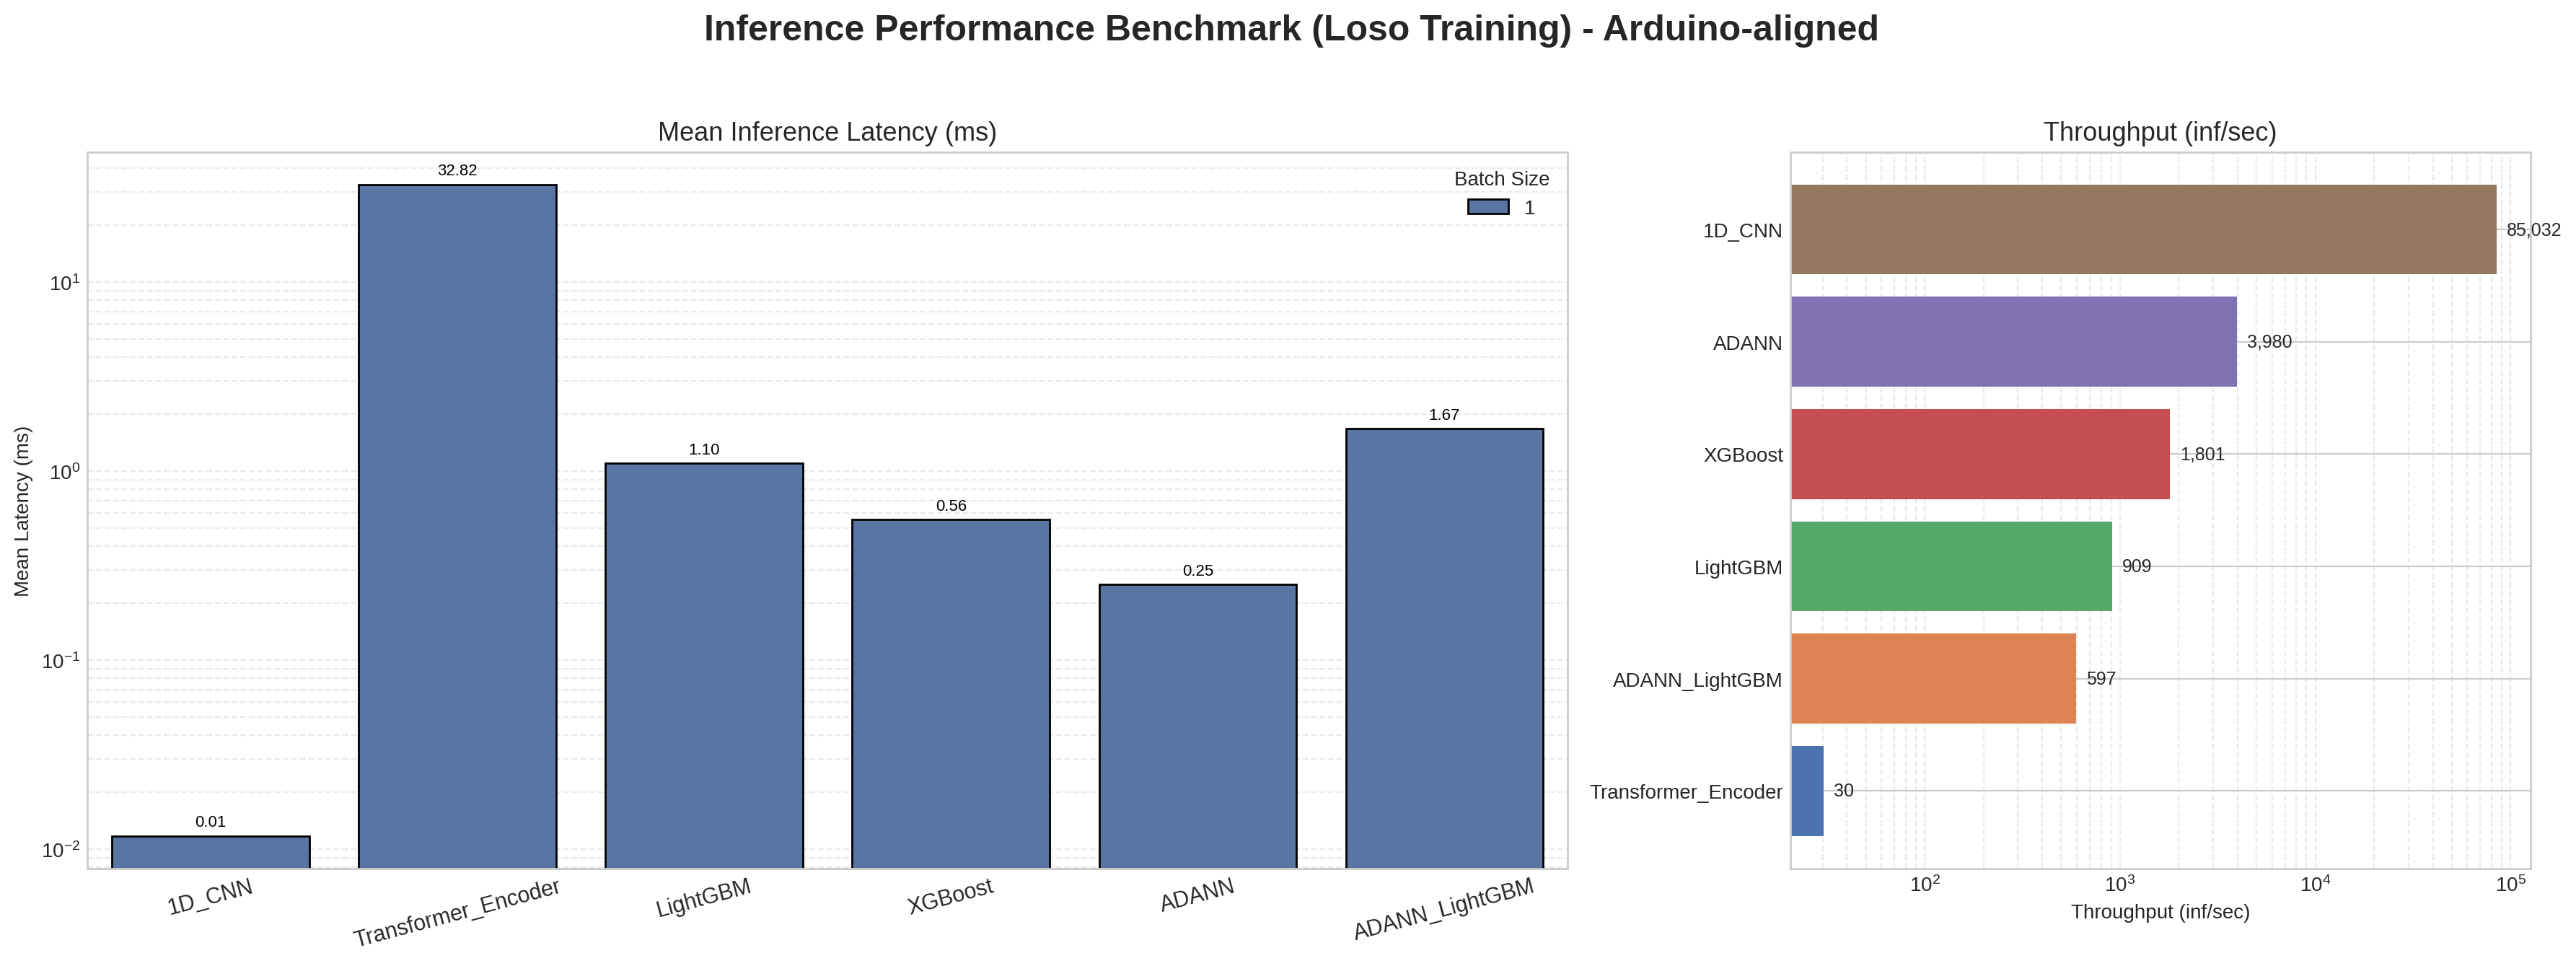

In [ ]:
# Section 3: Run benchmark (CPU Arduino-aligned)
# Set arduino_only=True to require Arduino models only (no fallback to full)
bench = CpuArduinoLatencyBenchmark(arduino_only=True)
bench.run_benchmark()
